In [1]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

vae = pipe.vae

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

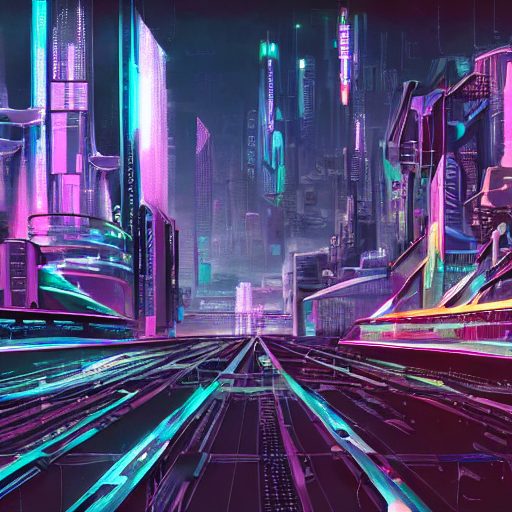

In [2]:
prompt = "A futuristic cyberpunk city"

image = pipe(prompt).images[0]

image

In [3]:
from torchvision import transforms

transform = transforms.ToTensor()

image_tensor = transform(image).unsqueeze(0).to("cuda").half()

latent = vae.encode(image_tensor).latent_dist.sample()

print(latent.shape)

torch.Size([1, 4, 64, 64])


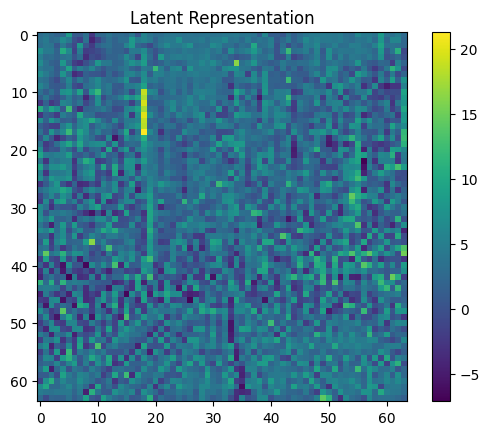

In [4]:
import matplotlib.pyplot as plt

latent_display = latent[0][0].detach().cpu().numpy()

plt.imshow(latent_display, cmap="viridis")

plt.title("Latent Representation")

plt.colorbar()

plt.show()

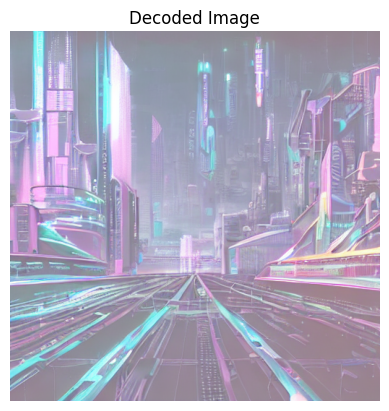

In [6]:
decoded = vae.decode(latent).sample

decoded = (decoded / 2 + 0.5).clamp(0, 1)

decoded_image = (
    decoded[0]
    .permute(1, 2, 0)
    .detach()
    .cpu()
    .float()   # IMPORTANT FIX
    .numpy()
)

plt.imshow(decoded_image)

plt.title("Decoded Image")

plt.axis("off")

plt.show()

In [7]:
image1 = pipe("A futuristic city").images[0]

image2 = pipe("A fantasy forest").images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [8]:
tensor1 = transform(image1).unsqueeze(0).to("cuda").half()
tensor2 = transform(image2).unsqueeze(0).to("cuda").half()

latent1 = vae.encode(tensor1).latent_dist.sample()
latent2 = vae.encode(tensor2).latent_dist.sample()

In [9]:
alpha = 0.5

interpolated_latent = (
    alpha * latent1 +
    (1 - alpha) * latent2
)

In [12]:
import gc
import torch

torch.cuda.empty_cache()

gc.collect()

5301

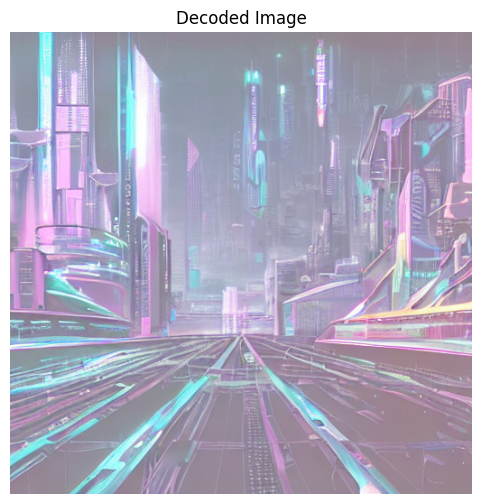

In [16]:
vae_cpu = vae.to("cpu").float()

latent_cpu = latent.detach().cpu().float()

with torch.no_grad():

    decoded = vae_cpu.decode(latent_cpu).sample

decoded = (decoded / 2 + 0.5).clamp(0, 1)

decoded_image = decoded[0]

decoded_image = decoded_image.permute(1, 2, 0)

decoded_image = decoded_image.numpy().astype("float32")

plt.figure(figsize=(6,6))

plt.imshow(decoded_image)

plt.title("Decoded Image")

plt.axis("off")

plt.show()